In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

from lipid_analysis import (
    create_lipid_dataset, 
    extract_structural_features, 
    calculate_srs_score, 
    classify_risk_level
)

raw_data = create_lipid_dataset(n_random=50)
features_data = extract_structural_features(raw_data)
scored_data = calculate_srs_score(features_data)
final_results = classify_risk_level(scored_data)

sns.set_theme(style="whitegrid")

display(final_results.head())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Molecule_Name,Carbon_Length,Double_Bonds,Isomer_Type,Data_Source,is_saturated,is_trans,is_cis,Risk_Score,Risk_Level
0,Palmitic Acid,16,0,none,Factual Reference,1,0,0,2.544444,Moderate Risk
1,Stearic Acid,18,0,none,Factual Reference,1,0,0,2.550000,Moderate Risk
2,Myristic Acid,14,0,none,Factual Reference,1,0,0,2.538889,Moderate Risk
3,Arachidic Acid,20,0,none,Factual Reference,1,0,0,2.555556,Moderate Risk
4,Oleic Acid,18,1,cis,Factual Reference,0,0,1,-1.450000,Low Risk


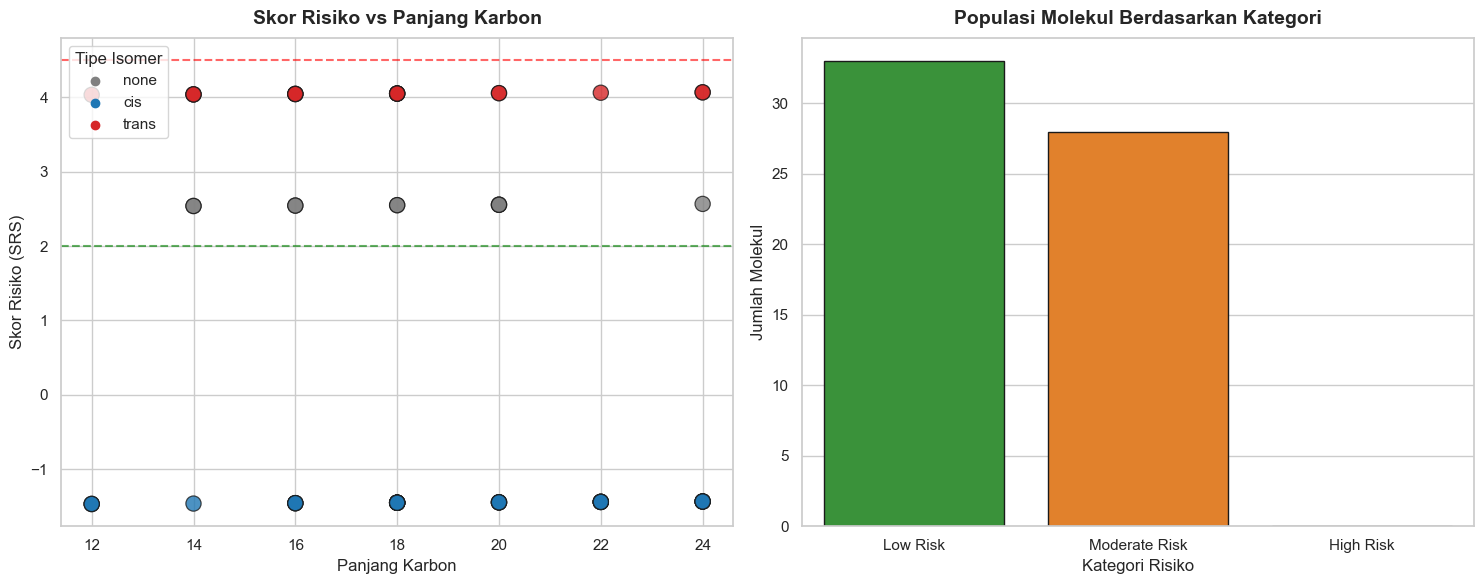

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=final_results, x='Carbon_Length', y='Risk_Score', hue='Isomer_Type', 
    palette={'none': 'gray', 'cis': '#1f77b4', 'trans': '#d62728'},
    s=120, alpha=0.8, ax=axes[0], edgecolor='k'
)
axes[0].set_title('Skor Risiko vs Panjang Karbon', fontsize=14, pad=10, fontweight='bold')
axes[0].set_xlabel('Panjang Karbon', fontsize=12)
axes[0].set_ylabel('Skor Risiko (SRS)', fontsize=12)
axes[0].axhline(y=4.5, color='red', linestyle='--', alpha=0.6)
axes[0].axhline(y=2.0, color='green', linestyle='--', alpha=0.6)
axes[0].legend(title='Tipe Isomer', loc='upper left')

sns.countplot(
    data=final_results, x='Risk_Level', 
    order=['Low Risk', 'Moderate Risk', 'High Risk'],
    palette={'Low Risk': '#2ca02c', 'Moderate Risk': '#ff7f0e', 'High Risk': '#d62728'},
    ax=axes[1], edgecolor='k'
)
axes[1].set_title('Populasi Molekul Berdasarkan Kategori', fontsize=14, pad=10, fontweight='bold')
axes[1].set_xlabel('Kategori Risiko', fontsize=12)
axes[1].set_ylabel('Jumlah Molekul', fontsize=12)

plt.tight_layout()
plt.show()


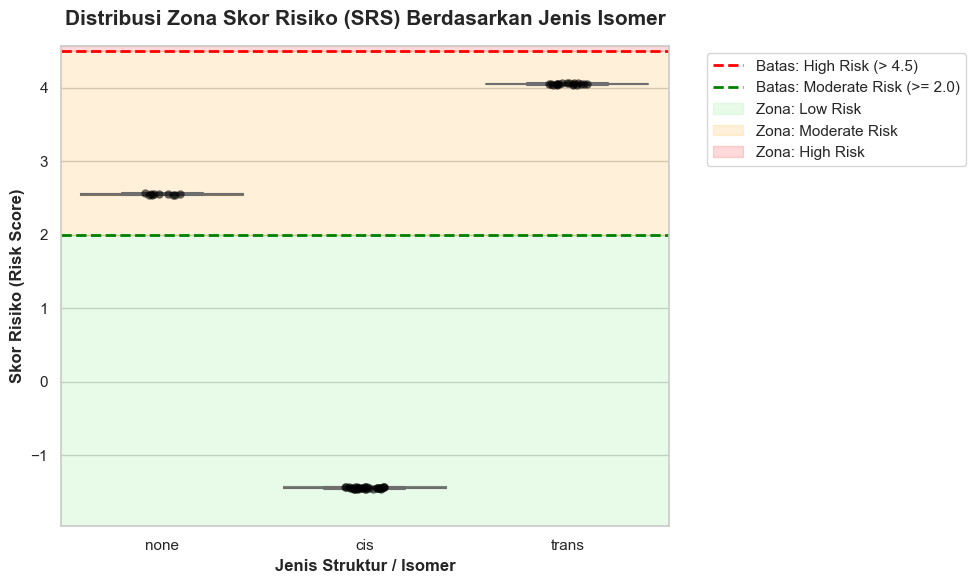

In [5]:
plt.figure(figsize=(10, 6))

# Plot dasar (Boxplot dan titik-titik data)
sns.boxplot(
    data=final_results, x='Isomer_Type', y='Risk_Score', 
    palette={'none': '#cccccc', 'cis': '#add8e6', 'trans': '#f08080'}, 
    showfliers=False
)
sns.stripplot(
    data=final_results, x='Isomer_Type', y='Risk_Score', 
    color='black', alpha=0.6, jitter=True, size=6
)

# Tentukan batas Y agar warna zonanya rapi menutupi seluruh background grafik
y_min = final_results['Risk_Score'].min() - 0.5
y_max = final_results['Risk_Score'].max() + 0.5

# Garis ambang batas (Threshold)
plt.axhline(y=4.5, color='red', linestyle='--', linewidth=2, label='Batas: High Risk (> 4.5)')
plt.axhline(y=2.0, color='green', linestyle='--', linewidth=2, label='Batas: Moderate Risk (>= 2.0)')

# Mewarnai background area (Risk Zones)
plt.axhspan(ymin=y_min, ymax=2.0, color='lightgreen', alpha=0.2, label='Zona: Low Risk')
plt.axhspan(ymin=2.0, ymax=4.5, color='orange', alpha=0.15, label='Zona: Moderate Risk')
plt.axhspan(ymin=4.5, ymax=y_max, color='red', alpha=0.15, label='Zona: High Risk')

# Formatting Teks dan Legend
plt.title('Distribusi Zona Skor Risiko (SRS) Berdasarkan Jenis Isomer', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Jenis Struktur / Isomer', fontsize=12, fontweight='bold')
plt.ylabel('Skor Risiko (Risk Score)', fontsize=12, fontweight='bold')
plt.ylim(y_min, y_max)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show() # Tampilkan grafik ketiga